In [1]:
%matplotlib ipympl
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

## Seaborn and Correlation Matrix

Today we are going to load seaborn and make one of their plots.  They have some nice plots and it is becoming mainstream.  https://seaborn.pydata.org/examples/index.html

If you don't have it.  install it.

## Read in our well data

In [2]:
df=pd.read_csv('well_data.csv')

List all the columns

In [3]:
df.columns

Index(['Well_ID', 'Lat', 'Lon', 'Depth', 'Drink', 'Si', 'P', 'S', 'Ca', 'Fe',
       'Ba', 'Na', 'Mg', 'K', 'Mn', 'As', 'Sr', 'F', 'Cl', 'SO4', 'Br'],
      dtype='object')

If you ever need to delete a column this is how you do it.   (not needed)

In [4]:
df = df.drop(['Well_ID','Drink'], axis=1)

Go back and find the columns you want to use and save it back to the dataframe.  

In [5]:
df=df[['As', 'Sr', 'Ca', 'P', 'Fe']]

Run seaborn pairplot. https://seaborn.pydata.org/generated/seaborn.pairplot.html

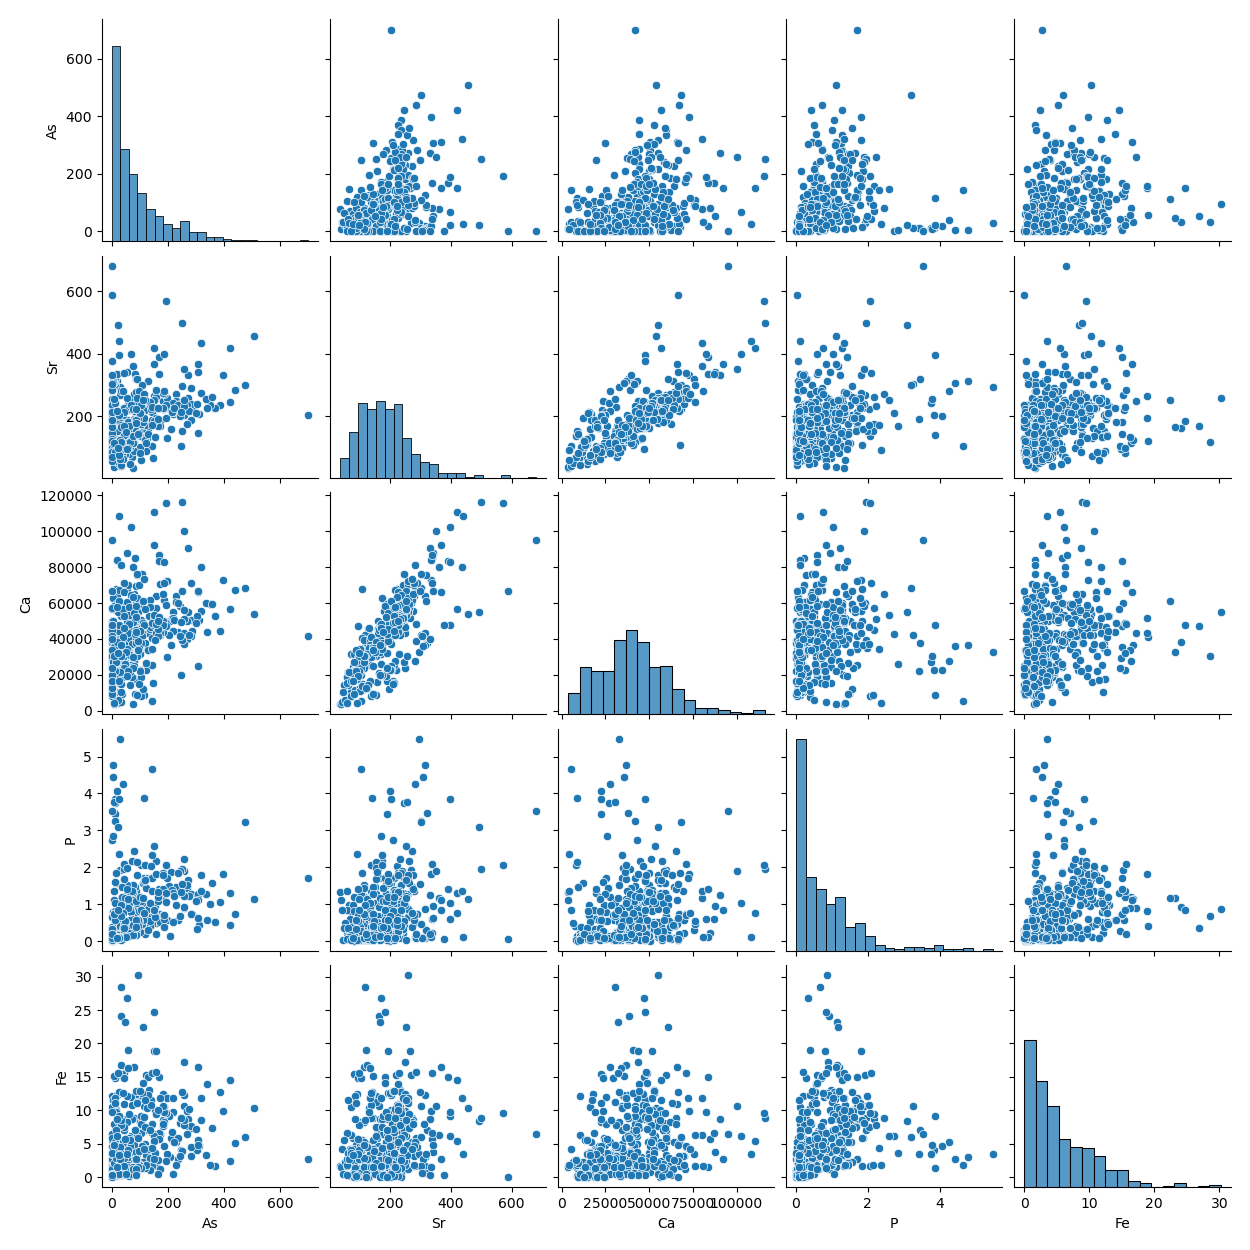

In [6]:
sns.pairplot(df)
plt.savefig('test.jpg')

Also you can color by a categorical value.  So add 'Drink' back in and use it to set hue

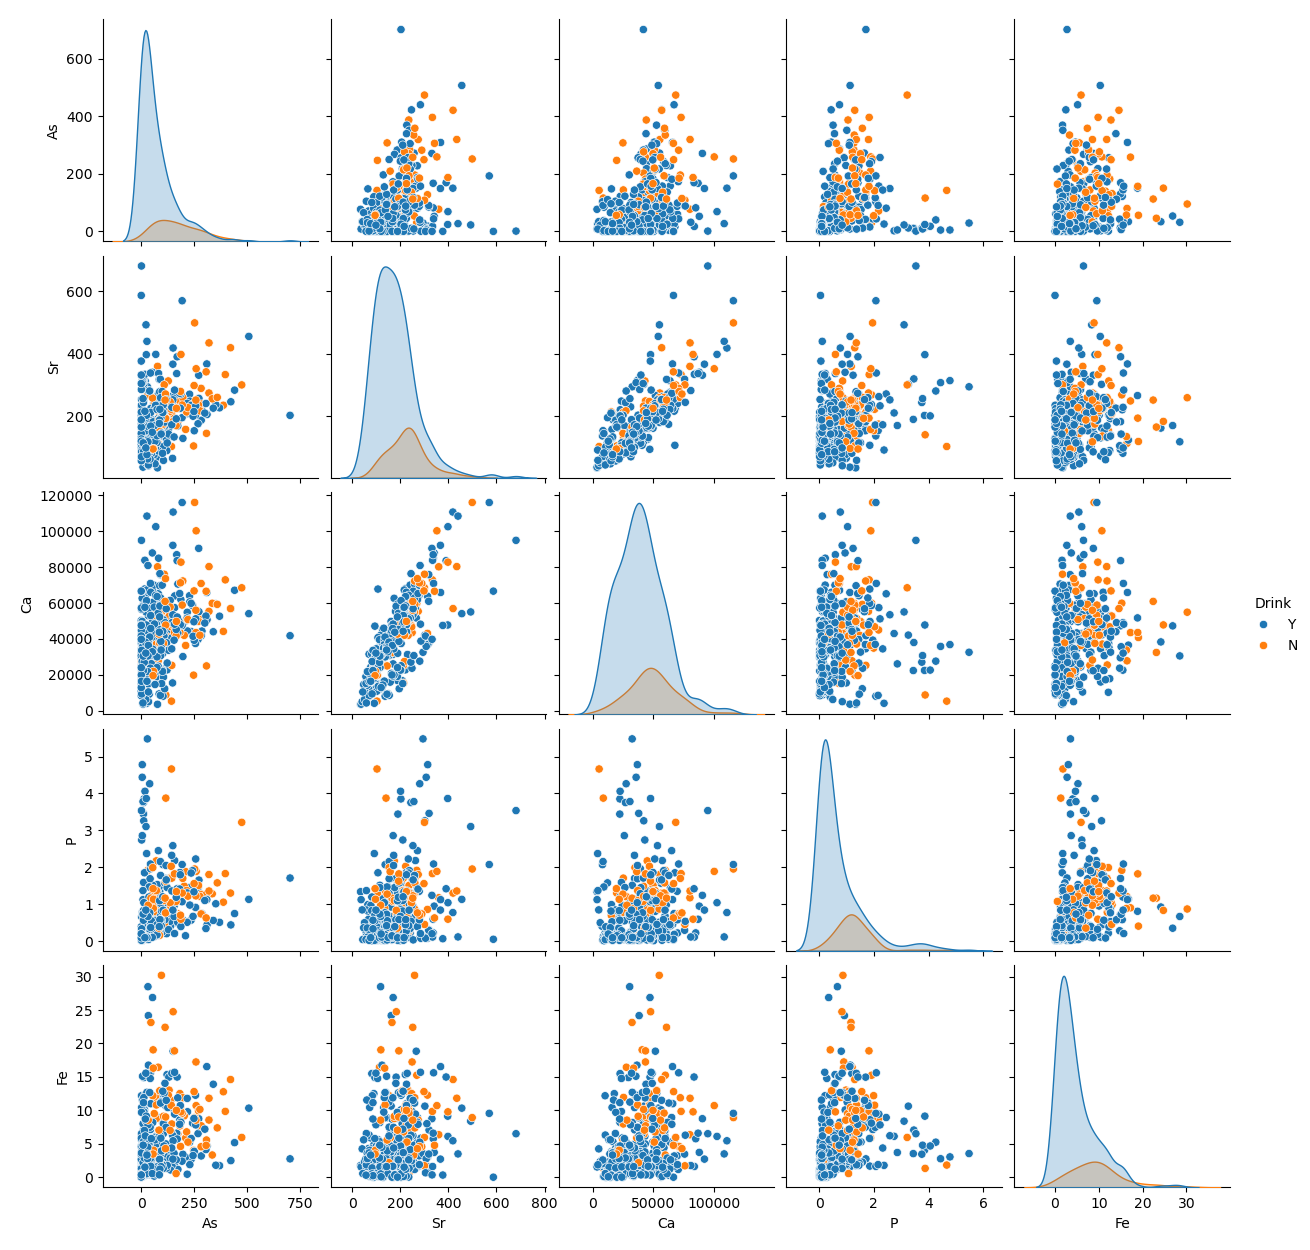

In [7]:
df=pd.read_csv('well_data.csv')
df=df[['As', 'Sr', 'Ca', 'P', 'Fe','Drink']]
sns.pairplot(df,hue='Drink')
plt.savefig('test.jpg')

### If it is easier you could do it by column number instead

In [9]:
df=pd.read_csv('well_data.csv')

In [10]:
for count,col in enumerate(df):
    print(count,col)

0 Well_ID
1 Lat
2 Lon
3 Depth
4 Drink
5 Si
6 P
7 S
8 Ca
9 Fe
10 Ba
11 Na
12 Mg
13 K
14 Mn
15 As
16 Sr
17 F
18 Cl
19 SO4
20 Br


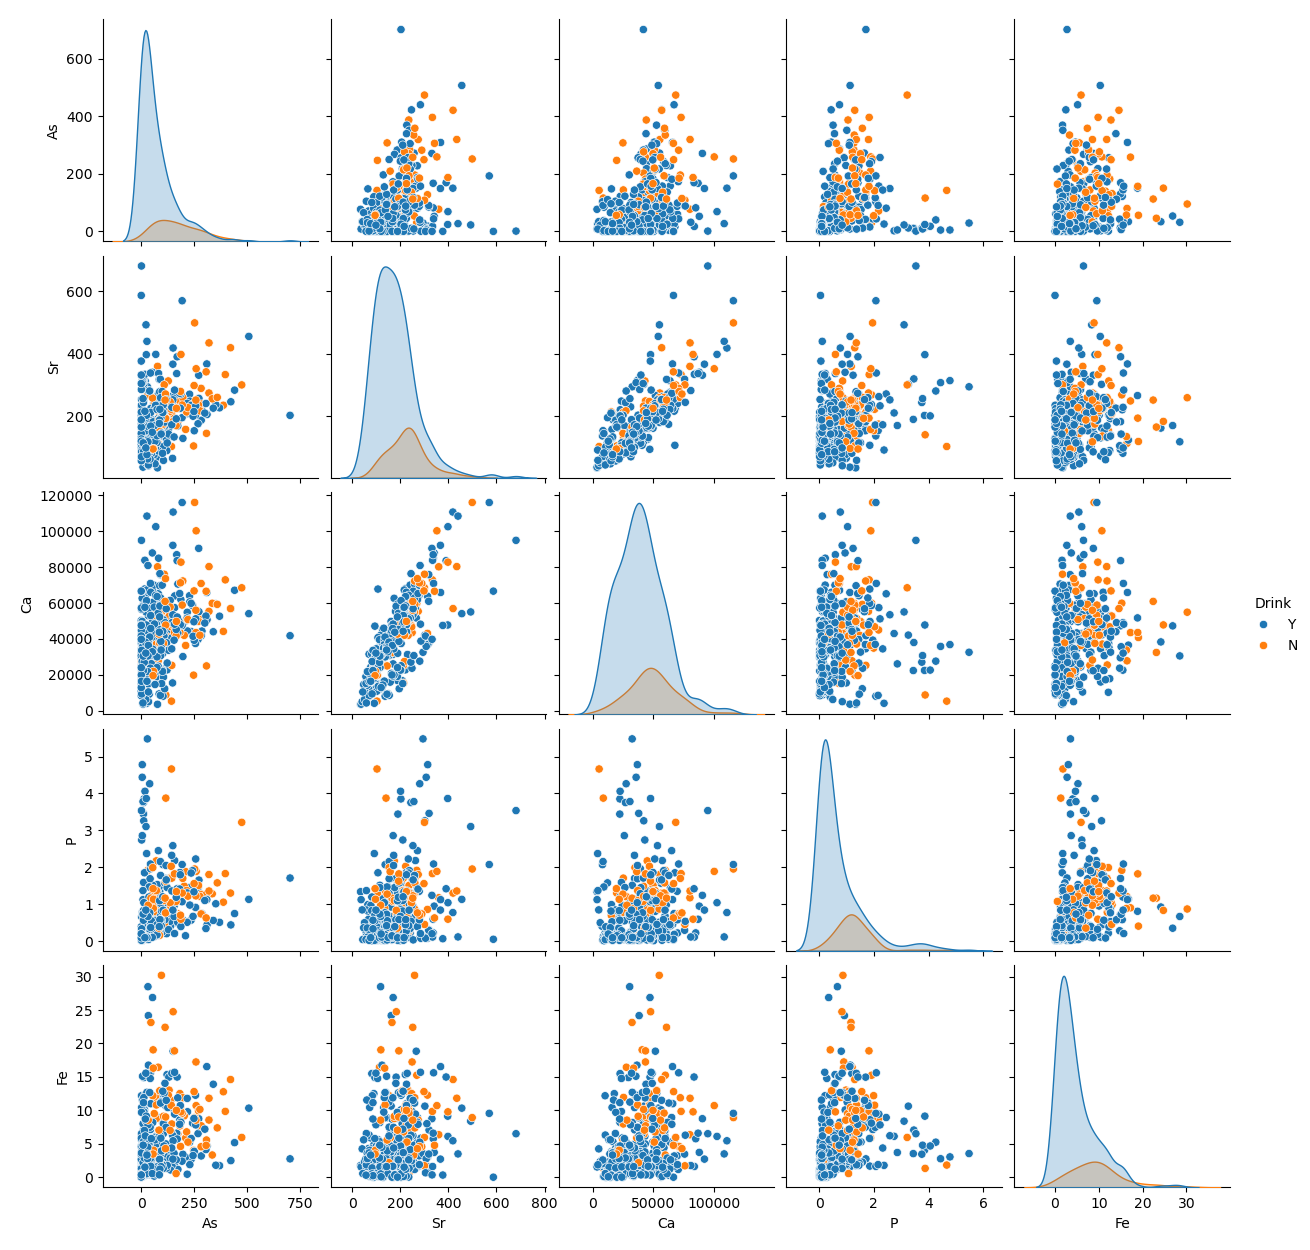

In [11]:

df=df.iloc[:,[15, 16, 8, 6, 9,4]]
sns.pairplot(df,hue='Drink')
plt.savefig('test.jpg')

## This is all extra material below that I found fun

But you don't get all the r-values or p-values.  Can you make an excel file of all of them?  I would
1.  Just take all the numerical data.  See first line for how I did it.
1.  Make a double for loop to go through the data
1.  Calculate the r2
1.  print to your new dataframe
1.  save to excel

In [35]:
df=pd.read_csv('well_data.csv')

df=df.select_dtypes(include=np.number)
df_r2=pd.DataFrame()

for i in df:
    for j in df:
        #print (i,j) #UNCOMMENT
        results=stats.linregress(*df[[i,j]].dropna().values.T)  
        df_r2.at[j,i]=results.rvalue**2
        
df_r2.to_excel('All_correlations.xlsx')

You can open your excel file or visualize in sseaborn. 

<Axes: >

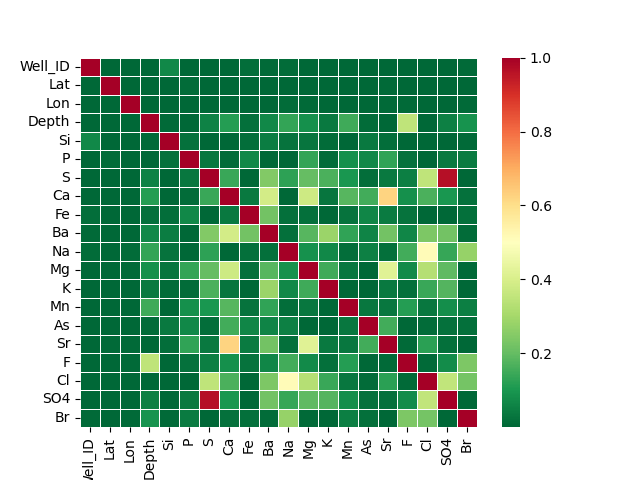

In [26]:
fig,ax=plt.subplots()
sns.heatmap(df_r2, cmap='RdYlGn_r', linewidths=0.5, annot=False,ax=ax)

Try with r-vlaues 

<Axes: >

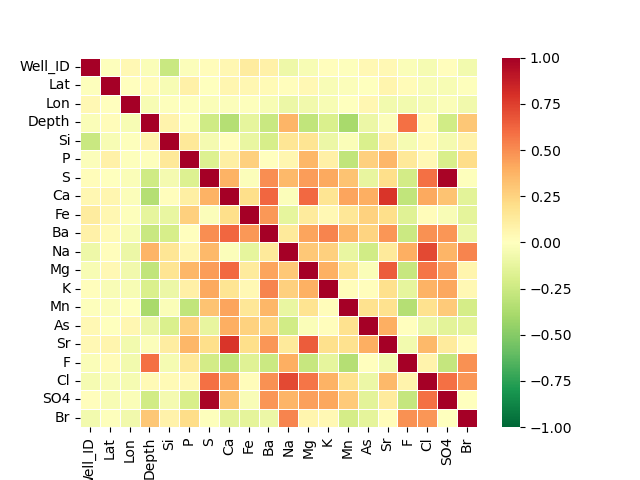

In [28]:
df=pd.read_csv('well_data.csv')

df=df.select_dtypes(include=np.number)
df_r2=pd.DataFrame()

for i in df:
    for j in df:
        results=stats.linregress(*df[[i,j]].dropna().values.T)
        df_r2.at[j,i]=results.rvalue

fig,ax=plt.subplots()
sns.heatmap(df_r2, cmap='RdYlGn_r', linewidths=0.5, annot=False,vmin=-1,vmax=1,ax=ax)

For excel I would do r-values and only save for when p-value is less than 0.01

<Axes: >

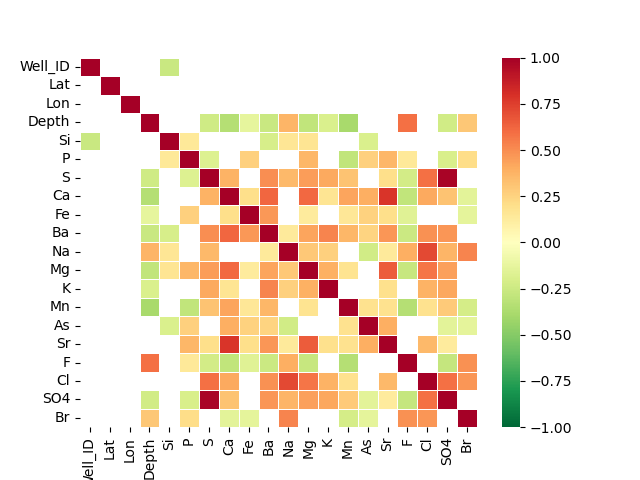

In [30]:
df=pd.read_csv('well_data.csv')

df=df.select_dtypes(include=np.number)
df_r2=pd.DataFrame()

for i in df:
    for j in df:
        results=stats.linregress(*df[[i,j]].dropna().values.T)
        if results.pvalue<0.01:
            df_r2.at[j,i]=results.rvalue
        else:
            df_r2.at[j,i]=np.nan
df_r2.to_excel('r-values.xlsx')

fig,ax=plt.subplots()
sns.heatmap(df_r2, cmap='RdYlGn_r', linewidths=0.5, annot=False,vmin=-1,vmax=1,ax=ax)

If column names are really long remember you can use iloc to chosse a datafram by column number

In [31]:
df.iloc[:,3:7]

,Depth,Si,P,S
0,45,NaN,NaN,NaN
1,60,NaN,NaN,NaN
2,60,NaN,NaN,NaN
3,50,48084.33842,0.936358,2085.570979
4,150,NaN,NaN,NaN
...,...,...,...,...
754,160,32379.64000,0.197380,3669.430000
755,60,25561.12000,0.090570,13771.370000
756,45,31319.48000,1.162550,38.300000
757,60,30605.53000,1.556120,4168.520000


In [32]:
df=pd.read_excel('Species-Arsenic-Data.xlsx')

In [36]:
for count, column in enumerate(df.columns):
    #print(count,column) #UNCOMMENT

SyntaxError: incomplete input (846520043.py, line 2)